<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/00_timeseries_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 시계열분석을 위한 통계기초 — 전체 실습

PPT의 핵심 개념을 Colab에서 직접 확인할 수 있도록 구성한 실습 노트북입니다.

각 주제는 다음 순서로 진행합니다.

1. **내용 설명**
2. **수식**
3. **실습 코드**
4. **결과**
5. **결과 해석**

> 그래프 제목·축·범례는 Google Colab의 한글 폰트 문제를 피하기 위해 **영어로 출력**합니다.  
> 설명과 해석은 한국어로 유지합니다.  
> 결과는 **화면에만 출력**하며 파일로 저장하지 않습니다.

## 강의 구성 개요

### 1부. 데이터를 숫자로 이해하기
- 데이터의 유형
- 평균·중앙값
- 분산·표준편차
- 공분산·상관관계

### 2부. 데이터에서 결론을 내리기
- 확률과 확률분포
- 모집단과 표본
- 신뢰구간
- 가설검정
- 회귀분석

### 3부. 통계에서 시계열로
- Lag
- 자기상관
- ACF
- 정상성
- White Noise
- Unit Root
- ADF / KPSS

# 0. 실행 환경

In [1]:
!pip -q install numpy pandas scipy statsmodels matplotlib yfinance

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss

np.random.seed(42)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10,4)

print("Environment ready.")

Environment ready.


# 1부. 데이터를 숫자로 이해하기

# 1-1. 데이터의 유형

## 내용 설명

통계분석의 시작은 모델이 아니라 데이터의 구조를 이해하는 것입니다.

- **Cross-sectional data**: 특정 시점에서 여러 개체를 관측
- **Time series data**: 같은 변수나 시스템을 시간 순서에 따라 반복 관측
- **Panel data**: 여러 개체를 시간에 따라 반복 관측

시계열에서는 관측치의 순서(Order)가 정보입니다.

## 수식

시계열은 보통 다음과 같이 나타냅니다.

$$
Y_1, Y_2, \ldots, Y_T
$$

여기서 $t$는 단순한 행 번호가 아니라 **시간 인덱스**입니다.

## 실습 코드

In [3]:
cross_section = pd.DataFrame({
    "Firm": ["A","B","C","D"],
    "Sales_2026": [100,130,95,160]
})

time_series = pd.DataFrame({
    "Month": ["Jan","Feb","Mar","Apr"],
    "Sales": [100,120,115,140]
})

panel = pd.DataFrame({
    "Firm": ["A","A","B","B","C","C"],
    "Month": ["Jan","Feb","Jan","Feb","Jan","Feb"],
    "Sales": [100,110,130,128,95,99]
})

print("Cross-sectional data")
display(cross_section)

print("Time series data")
display(time_series)

print("Panel data")
display(panel)

Cross-sectional data


,Firm,Sales_2026
0,A,100
1,B,130
2,C,95
3,D,160


Time series data


,Month,Sales
0,Jan,100
1,Feb,120
2,Mar,115
3,Apr,140


Panel data


,Firm,Month,Sales
0,A,Jan,100
1,A,Feb,110
2,B,Jan,130
3,B,Feb,128
4,C,Jan,95
5,C,Feb,99


## 결과

세 가지 데이터 구조가 각각 표로 출력됩니다.

## 결과 해석

횡단면은 개체 간 차이, 시계열은 시간 변화, 패널은 개체 차이와 시간 변화를 동시에 다룹니다.

# 1-2. 같은 숫자, 다른 시계열

## 내용 설명

평균이 같더라도 값이 나타나는 순서가 다르면 시계열의 구조는 달라집니다.

## 수식

$$
A=(1,2,1,2,1,2), \qquad B=(1,1,1,2,2,2)
$$

$$
\bar{A}=\bar{B}=1.5
$$

## 실습 코드

Mean(A) = 1.5
Mean(B) = 1.5


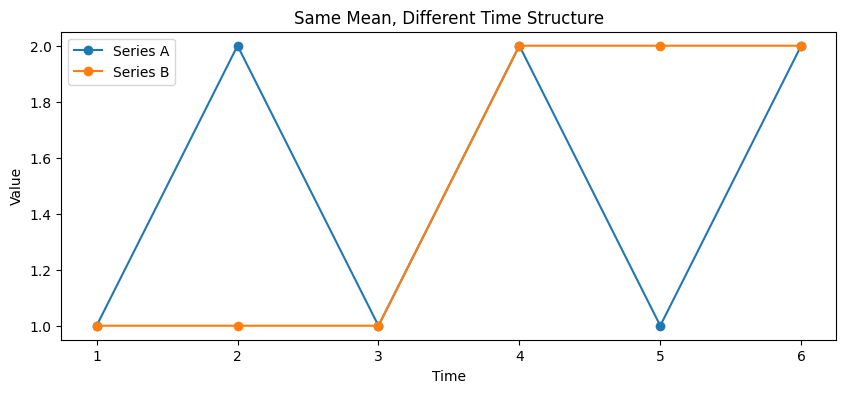

In [4]:
A = np.array([1,2,1,2,1,2])
B = np.array([1,1,1,2,2,2])

print("Mean(A) =", A.mean())
print("Mean(B) =", B.mean())

plt.plot(range(1,7), A, marker="o", label="Series A")
plt.plot(range(1,7), B, marker="o", label="Series B")
plt.title("Same Mean, Different Time Structure")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 결과

두 시계열의 평균은 같지만 그래프 형태는 다르게 나타납니다.

## 결과 해석

시계열에서는 **값뿐 아니라 순서가 정보**입니다.

# 1-3. 평균 Mean

## 내용 설명

평균은 여러 관측값을 하나의 대표값으로 요약하는 가장 기본적인 통계량입니다.
시계열에서는 평균 자체뿐 아니라 평균이 시간에 따라 안정적인지도 중요합니다.

## 수식

$$
\bar{x}
=
\frac{1}{n}\sum_{i=1}^{n}x_i
$$

## 실습 코드

Data: [ 8 10 12 14 16]
Mean: 12.0


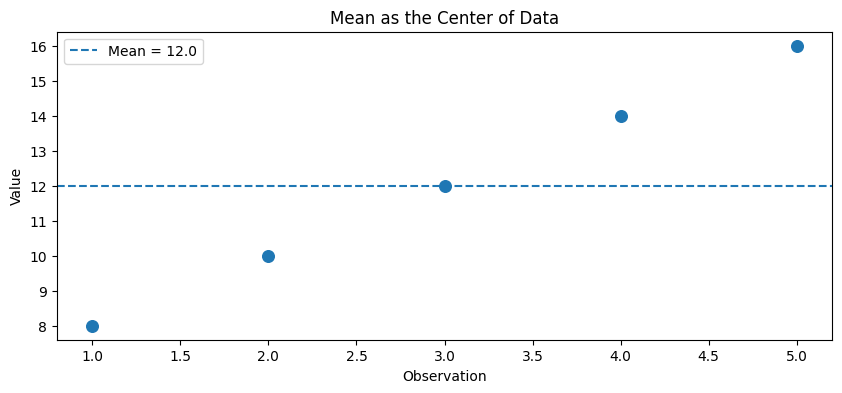

In [5]:
x = np.array([8,10,12,14,16])

print("Data:", x)
print("Mean:", x.mean())

plt.scatter(range(1,len(x)+1), x, s=70)
plt.axhline(x.mean(), linestyle="--", label=f"Mean = {x.mean():.1f}")
plt.title("Mean as the Center of Data")
plt.xlabel("Observation")
plt.ylabel("Value")
plt.legend()
plt.show()

## 결과

수평선이 데이터의 평균 위치를 보여줍니다.

## 결과 해석

평균은 중심을 설명하지만 변동성이나 시간 패턴까지 설명하지는 못합니다.

# 1-4. 평균의 함정과 중앙값 Median

## 내용 설명

평균은 이상치에 민감합니다. 중앙값은 데이터를 정렬했을 때 가운데 위치한 값으로, 이상치가 있는 상황에서 더 안정적일 수 있습니다.

## 수식

평균:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

중앙값은 정렬된 표본의 중앙 순서값입니다.

## 실습 코드

In [6]:
regular = np.array([10,11,12,13,14])
with_outlier = np.array([10,11,12,13,100])

result = pd.DataFrame({
    "Dataset": ["Regular","With Outlier"],
    "Mean": [regular.mean(), with_outlier.mean()],
    "Median": [np.median(regular), np.median(with_outlier)]
})
display(result)

,Dataset,Mean,Median
0,Regular,12.0,12.0
1,With Outlier,29.2,12.0


## 결과

이상치가 포함되면 평균은 크게 이동하지만 중앙값은 비교적 안정적입니다.

## 결과 해석

비대칭 분포나 극단값이 있는 데이터에서는 평균과 중앙값을 함께 보는 것이 좋습니다.

# 1-5. 평균과 중앙값은 언제 달라지는가?

## 내용 설명

분포가 비대칭이면 평균과 중앙값이 달라질 수 있습니다.

## 수식

대칭분포:

$$
Mean \approx Median
$$

오른쪽 꼬리:

$$
Mean > Median
$$

## 실습 코드

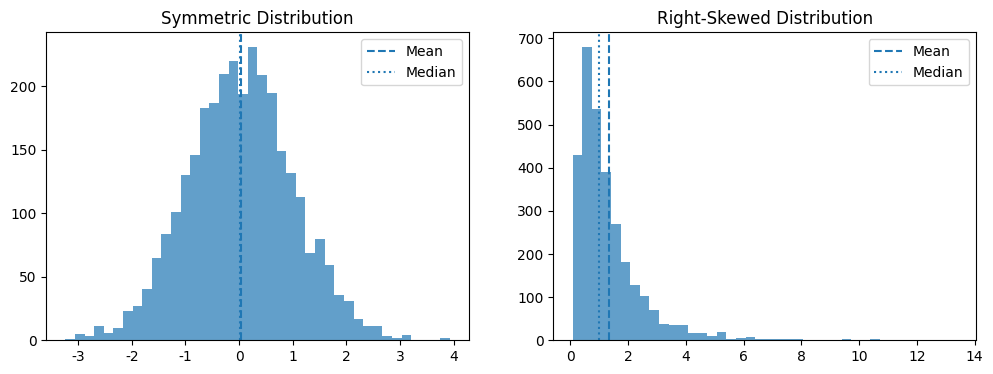

In [7]:
symmetric = np.random.normal(0,1,3000)
right_skewed = np.random.lognormal(mean=0, sigma=0.8, size=3000)

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(symmetric, bins=40, alpha=0.7)
axes[0].axvline(np.mean(symmetric), linestyle="--", label="Mean")
axes[0].axvline(np.median(symmetric), linestyle=":", label="Median")
axes[0].set_title("Symmetric Distribution")
axes[0].legend()

axes[1].hist(right_skewed, bins=40, alpha=0.7)
axes[1].axvline(np.mean(right_skewed), linestyle="--", label="Mean")
axes[1].axvline(np.median(right_skewed), linestyle=":", label="Median")
axes[1].set_title("Right-Skewed Distribution")
axes[1].legend()

plt.show()

## 결과

대칭분포에서는 평균과 중앙값이 비슷하지만, 오른쪽 꼬리가 긴 분포에서는 평균이 더 오른쪽으로 이동합니다.

## 결과 해석

분포의 형태를 함께 보지 않으면 중심 위치를 오해할 수 있습니다.

# 1-6. 편차와 분산 Variance

## 내용 설명

분산은 관측값이 평균으로부터 얼마나 퍼져 있는지를 나타냅니다.

## 수식

편차:

$$
x_i-\bar{x}
$$

표본분산:

$$
s^2
=
\frac{1}{n-1}
\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

편차를 제곱하는 이유는 양수와 음수 편차의 상쇄를 막기 위해서입니다.

## 실습 코드

,Series,Mean,Variance
0,C,10.0,0.5
1,D,10.0,40.0


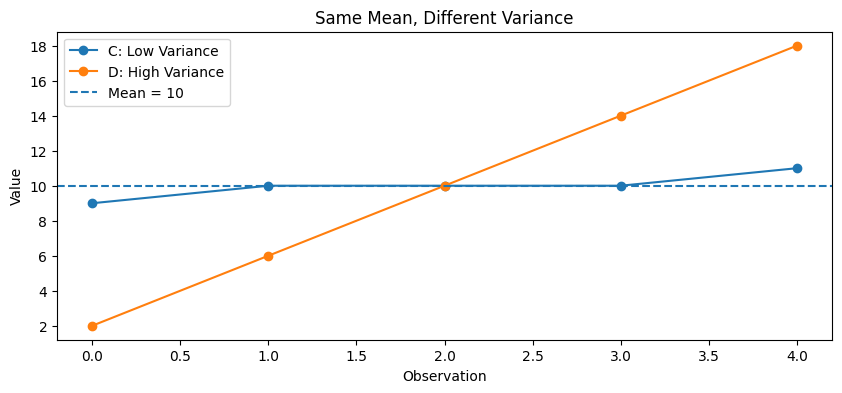

In [8]:
C = np.array([9,10,10,10,11])
D = np.array([2,6,10,14,18])

result = pd.DataFrame({
    "Series": ["C","D"],
    "Mean": [C.mean(), D.mean()],
    "Variance": [C.var(ddof=1), D.var(ddof=1)]
})
display(result)

plt.plot(C, marker="o", label="C: Low Variance")
plt.plot(D, marker="o", label="D: High Variance")
plt.axhline(10, linestyle="--", label="Mean = 10")
plt.title("Same Mean, Different Variance")
plt.xlabel("Observation")
plt.ylabel("Value")
plt.legend()
plt.show()

## 결과

두 데이터의 평균은 같지만 D의 분산이 훨씬 큽니다.

## 결과 해석

분산은 데이터의 중심이 아니라 **퍼짐과 변동성**을 설명합니다.

# 1-7. 왜 표본분산은 n-1로 나누는가?

## 내용 설명

표본평균을 사용하면 자유도 하나를 이미 사용한 셈이므로, 표본분산은 $n-1$로 나누어 편향을 보정합니다.

## 수식

모집단 분산:

$$
\sigma^2
=
\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2
$$

표본분산:

$$
s^2
=
\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

## 실습 코드

In [9]:
x = np.array([4,5,7,8,11])

print("Variance using n   :", np.var(x, ddof=0))
print("Variance using n-1 :", np.var(x, ddof=1))

Variance using n   : 6.0
Variance using n-1 : 7.5


## 결과

두 방식으로 계산한 분산 값이 다르게 출력됩니다.

## 결과 해석

표본으로 모집단 분산을 추정할 때 일반적으로 $n-1$ 보정을 사용합니다.

# 1-8. 표준편차 Standard Deviation

## 내용 설명

표준편차는 분산의 제곱근으로 원래 데이터와 같은 단위를 갖습니다.

## 수식

$$
s=\sqrt{s^2}
$$

## 실습 코드

In [10]:
asset = np.array([0.3,-0.1,0.5,-0.4,0.2])

print("Mean return (%) =", asset.mean())
print("Variance =", asset.var(ddof=1))
print("Standard deviation (%) =", asset.std(ddof=1))

Mean return (%) = 0.09999999999999999
Variance = 0.125
Standard deviation (%) = 0.3535533905932738


## 결과

표준편차가 수익률과 같은 % 단위로 출력됩니다.

## 결과 해석

금융 시계열에서는 표준편차가 변동성(volatility)의 기본 언어로 사용됩니다.

# 1-9. 공분산 Covariance

## 내용 설명

공분산은 두 변수가 평균을 기준으로 같은 방향으로 움직이는지, 반대 방향으로 움직이는지를 측정합니다.

## 수식

$$
Cov(X,Y)
=
E[(X-E[X])(Y-E[Y])]
$$

표본 공분산:

$$
s_{XY}
=
\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

## 실습 코드

Positive covariance: 17.359223933889904
Negative covariance: -17.474513280071214


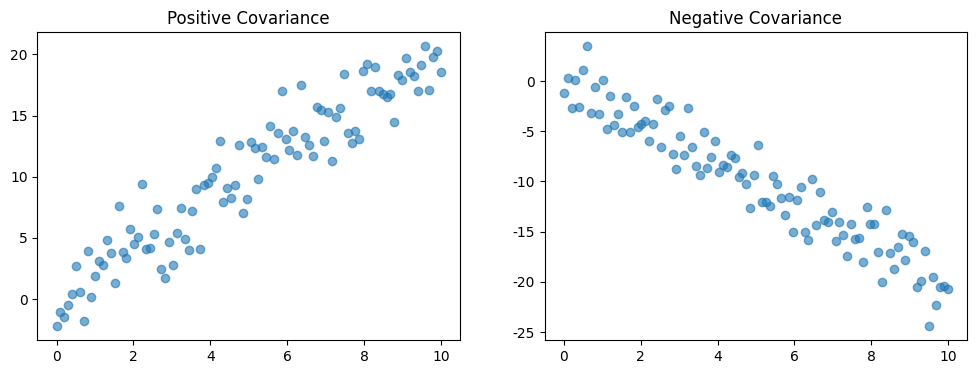

In [11]:
x = np.linspace(0,10,100)
y_pos = 2*x + np.random.normal(0,2,100)
y_neg = -2*x + np.random.normal(0,2,100)

print("Positive covariance:", np.cov(x, y_pos, ddof=1)[0,1])
print("Negative covariance:", np.cov(x, y_neg, ddof=1)[0,1])

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].scatter(x, y_pos, alpha=0.6)
axes[0].set_title("Positive Covariance")
axes[1].scatter(x, y_neg, alpha=0.6)
axes[1].set_title("Negative Covariance")
plt.show()

## 결과

같은 방향으로 움직이면 양의 공분산, 반대 방향이면 음의 공분산이 나타납니다.

## 결과 해석

공분산은 방향을 알려주지만 단위의 영향을 받습니다.

# 1-10. 상관계수 Correlation

## 내용 설명

상관계수는 공분산을 각 변수의 표준편차로 나누어 표준화한 값입니다.

## 수식

$$
\rho_{XY}
=
\frac{Cov(X,Y)}{\sigma_X\sigma_Y}
$$

$$
-1\le\rho_{XY}\le1
$$

## 실습 코드

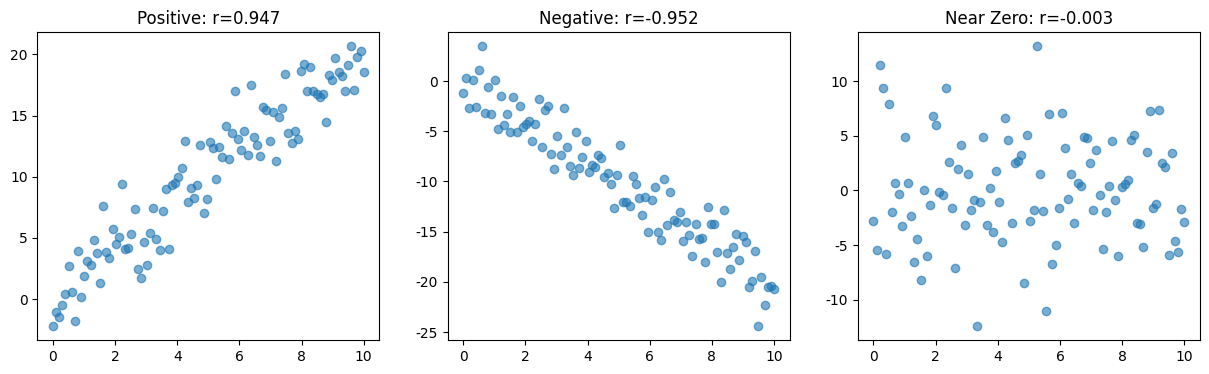

,Pattern,Correlation
0,Positive,0.947269
1,Negative,-0.952380
2,Near Zero,-0.003082


In [12]:
y_none = np.random.normal(0,5,100)

datasets = [("Positive", y_pos), ("Negative", y_neg), ("Near Zero", y_none)]

fig, axes = plt.subplots(1,3, figsize=(15,4))
rows = []

for ax, (name, y) in zip(axes, datasets):
    r = np.corrcoef(x,y)[0,1]
    rows.append([name, r])
    ax.scatter(x,y,alpha=0.6)
    ax.set_title(f"{name}: r={r:.3f}")

plt.show()
display(pd.DataFrame(rows, columns=["Pattern","Correlation"]))

## 결과

각 관계의 상관계수가 -1과 1 사이 값으로 출력됩니다.

## 결과 해석

상관계수는 방향과 강도를 동시에 보여주지만 인과관계를 증명하지는 않습니다.

# 1-11. Spurious Correlation

## 내용 설명

시계열에서는 두 변수가 공통적인 추세를 가지면 실제 관계가 없어도 높은 상관이 나타날 수 있습니다.

## 실습 코드

Correlation = 0.50880071615649


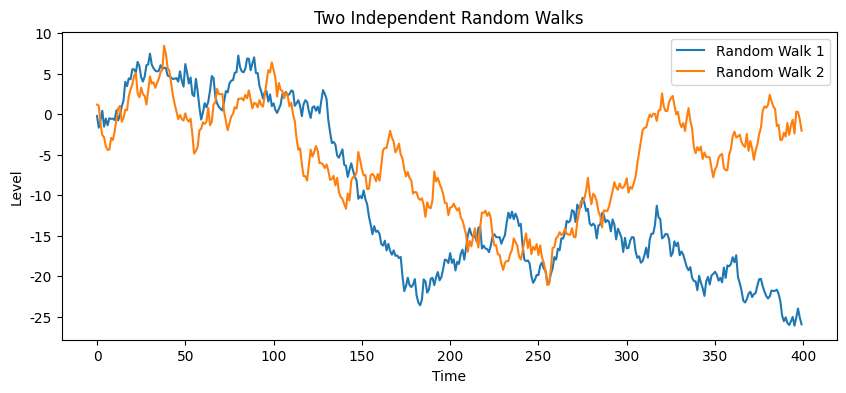

In [13]:
T = 400
rw1 = np.cumsum(np.random.normal(0,1,T))
rw2 = np.cumsum(np.random.normal(0,1,T))

print("Correlation =", np.corrcoef(rw1,rw2)[0,1])

plt.plot(rw1, label="Random Walk 1")
plt.plot(rw2, label="Random Walk 2")
plt.title("Two Independent Random Walks")
plt.xlabel("Time")
plt.ylabel("Level")
plt.legend()
plt.show()

## 결과

서로 독립적으로 만든 두 Random Walk도 표본에 따라 높은 상관을 보일 수 있습니다.

## 결과 해석

시계열에서는 상관계수만으로 관계를 판단하면 위험합니다. 정상성 검토가 필요한 이유입니다.

# 2부. 데이터에서 결론을 내리기

# 2-1. 확률 Probability

## 내용 설명

확률은 사건이 발생할 가능성을 0과 1 사이의 숫자로 표현합니다.

## 수식

$$
0\le P(A)\le1
$$

## 실습 코드

In [14]:
coin = np.random.choice(["Head","Tail"], size=10000, p=[0.5,0.5])
display(pd.Series(coin).value_counts(normalize=True))

,proportion
Tail,0.5052
Head,0.4948


## 결과

Head와 Tail의 상대빈도가 약 0.5 근처로 나타납니다.

## 결과 해석

확률은 단일 사건을 확정하는 값이 아니라 반복되는 불확실성의 구조를 나타냅니다.

# 2-2. 확률변수 Random Variable

## 내용 설명

확률변수는 불확실한 결과를 숫자로 표현한 변수입니다. 미래 시계열 값도 관측 전에는 확률변수입니다.

## 수식

예를 들어 내일 수익률은

$$
R_{t+1}
$$

과 같이 나타낼 수 있습니다.

## 실습 코드

Mean = 0.04862603835190729
Std  = 0.9932177208613908


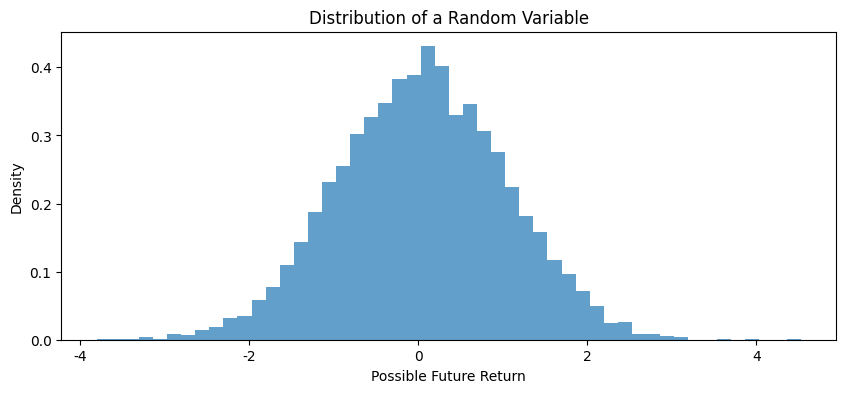

In [15]:
future_returns = np.random.normal(loc=0.05, scale=1.0, size=10000)

print("Mean =", future_returns.mean())
print("Std  =", future_returns.std(ddof=1))

plt.hist(future_returns, bins=50, density=True, alpha=0.7)
plt.title("Distribution of a Random Variable")
plt.xlabel("Possible Future Return")
plt.ylabel("Density")
plt.show()

## 결과

가능한 미래 수익률 값들이 분포 형태로 나타납니다.

## 결과 해석

예측은 하나의 숫자만이 아니라 가능한 값들의 분포를 함께 이해해야 합니다.

# 2-3. 정규분포 Normal Distribution

## 내용 설명

정규분포는 평균과 분산으로 정의되는 대표적인 연속확률분포입니다.

## 수식

$$
X\sim N(\mu,\sigma^2)
$$

## 실습 코드

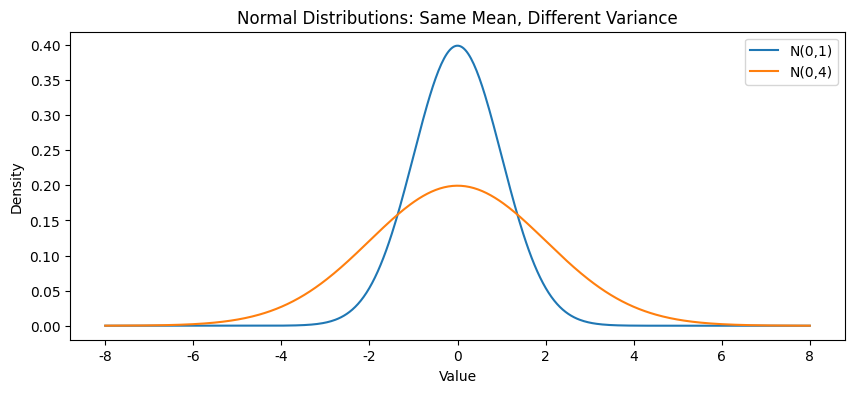

In [16]:
xx = np.linspace(-8,8,500)
pdf1 = stats.norm.pdf(xx, loc=0, scale=1)
pdf2 = stats.norm.pdf(xx, loc=0, scale=2)

plt.plot(xx,pdf1,label="N(0,1)")
plt.plot(xx,pdf2,label="N(0,4)")
plt.title("Normal Distributions: Same Mean, Different Variance")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## 결과

두 분포의 평균은 같지만 분산이 큰 분포가 더 넓게 퍼집니다.

## 결과 해석

평균은 위치, 분산은 퍼짐을 결정합니다.

# 2-4. 68–95–99.7 Rule

## 내용 설명

정규분포에서는 평균으로부터 몇 표준편차 떨어져 있는지에 따라 포함되는 값의 비율을 해석할 수 있습니다.

## 수식

$$
P(\mu-\sigma\le X\le\mu+\sigma)\approx0.68
$$

$$
P(\mu-2\sigma\le X\le\mu+2\sigma)\approx0.95
$$

$$
P(\mu-3\sigma\le X\le\mu+3\sigma)\approx0.997
$$

## 실습 코드

In [17]:
z = np.random.normal(0,1,1_000_000)

rule = pd.DataFrame({
    "Range": ["±1σ","±2σ","±3σ"],
    "Coverage (%)": [
        np.mean(np.abs(z)<=1)*100,
        np.mean(np.abs(z)<=2)*100,
        np.mean(np.abs(z)<=3)*100
    ]
})
display(rule)

,Range,Coverage (%)
0,±1σ,68.2527
1,±2σ,95.4395
2,±3σ,99.7362


## 결과

모의실험 결과가 약 68%, 95%, 99.7%에 가까워집니다.

## 결과 해석

이 규칙은 정규분포를 전제로 하며 현실 데이터가 항상 이 규칙을 따르는 것은 아닙니다.

# 2-5. Fat Tail

## 내용 설명

현실 데이터에서는 정규분포보다 극단값이 더 자주 나타나는 Fat Tail이 존재할 수 있습니다.

## 실습 코드

,Distribution,P(|X|>3) (%)
0,Normal,0.302
1,t(df=3),5.837


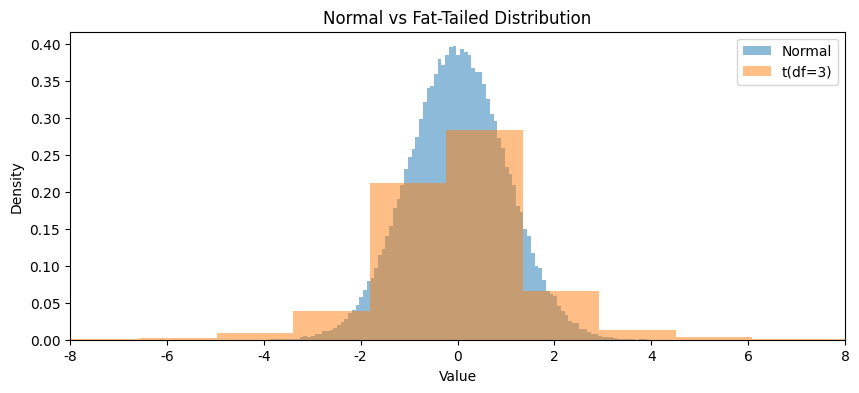

In [18]:
normal = np.random.normal(0,1,100000)
tdata = stats.t.rvs(df=3, size=100000, random_state=42)

comparison = pd.DataFrame({
    "Distribution": ["Normal","t(df=3)"],
    "P(|X|>3) (%)": [
        np.mean(np.abs(normal)>3)*100,
        np.mean(np.abs(tdata)>3)*100
    ]
})
display(comparison)

plt.hist(normal, bins=120, density=True, alpha=0.5, label="Normal")
plt.hist(tdata, bins=120, density=True, alpha=0.5, label="t(df=3)")
plt.xlim(-8,8)
plt.title("Normal vs Fat-Tailed Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## 결과

t 분포에서 극단값이 더 자주 발생합니다.

## 결과 해석

금융수익률처럼 꼬리가 두꺼운 데이터에서는 정규성 가정만으로 위험을 설명하기 어려울 수 있습니다.

# 2-6. 모집단과 표본

## 내용 설명

모집단은 관심 있는 전체 데이터 생성 과정이고, 표본은 실제로 관측한 일부 데이터입니다.

## 수식

모집단 모수:

$$
\mu,\quad\sigma^2
$$

표본 통계량:

$$
\bar{x},\quad s^2
$$

## 실습 코드

In [19]:
population = np.random.normal(50,10,1_000_000)
sample = np.random.choice(population, size=50, replace=False)

print("Population mean:", population.mean())
print("Sample mean:", sample.mean())
print("Population variance:", population.var())
print("Sample variance:", sample.var(ddof=1))

Population mean: 49.99527930323014
Sample mean: 53.353964434316396
Population variance: 100.13471417075726
Sample variance: 123.96271954059328


## 결과

표본 통계량은 모집단 모수와 비슷하지만 정확히 같지는 않습니다.

## 결과 해석

표본을 이용해 모집단을 추론하기 때문에 추정에는 항상 불확실성이 존재합니다.

# 2-7. 표준오차 Standard Error

## 내용 설명

표준오차는 표본평균 같은 추정량 자체가 얼마나 불확실한지를 나타냅니다.

## 수식

$$
SE(\bar{X})=\frac{s}{\sqrt{n}}
$$

## 실습 코드

In [20]:
sample_sizes = [10,30,100]
rows = []

for n in sample_sizes:
    means = []
    for _ in range(3000):
        s = np.random.choice(population, size=n, replace=True)
        means.append(s.mean())
    rows.append([n, np.mean(means), np.std(means, ddof=1)])

result = pd.DataFrame(rows, columns=["Sample Size","Mean of Sample Means","Approx. SE"])
display(result)

,Sample Size,Mean of Sample Means,Approx. SE
0,10,49.932529,3.133422
1,30,49.940960,1.800409
2,100,49.982829,0.994864


## 결과

표본크기가 커질수록 표본평균의 표준편차가 감소합니다.

## 결과 해석

표준편차는 데이터의 퍼짐, 표준오차는 추정량의 불확실성입니다.

# 2-8. 신뢰구간 Confidence Interval

## 내용 설명

신뢰구간은 점추정값 하나가 아니라 추정의 불확실성을 범위로 표현합니다.

## 수식

$$
\text{Estimate}
\pm
\text{Critical Value}\times SE
$$

정규근사 예:

$$
\bar{x}\pm1.96SE
$$

## 실습 코드

In [21]:
sample = np.random.normal(50,10,40)

mean = sample.mean()
se = stats.sem(sample)
low, high = stats.t.interval(0.95, df=len(sample)-1, loc=mean, scale=se)

display(pd.DataFrame({
    "Sample Mean": [mean],
    "Standard Error": [se],
    "CI Lower": [low],
    "CI Upper": [high]
}))

,Sample Mean,Standard Error,CI Lower,CI Upper
0,48.974305,1.764004,45.406271,52.542339


## 결과

표본평균과 함께 95% 신뢰구간의 하한과 상한이 출력됩니다.

## 결과 해석

신뢰구간은 추정값의 불확실성을 함께 보여주는 방법입니다.

# 2-9. 95% 신뢰구간의 반복표본 의미

## 내용 설명

95% 신뢰구간은 같은 절차를 반복했을 때 만들어지는 많은 구간 중 약 95%가 참값을 포함하도록 구성됩니다.

## 실습 코드

In [22]:
true_mu = 50
covered = []

for _ in range(500):
    s = np.random.normal(true_mu,10,30)
    m = s.mean()
    se = stats.sem(s)
    low, high = stats.t.interval(0.95, df=29, loc=m, scale=se)
    covered.append(low <= true_mu <= high)

print("Coverage rate =", np.mean(covered))

Coverage rate = 0.948


## 결과

참값 포함 비율이 대체로 0.95 근처로 나타납니다.

## 결과 해석

신뢰구간을 반복표본 관점에서 이해하면 “이번 구간에 참값이 있을 확률 95%”라는 단순한 오해를 피할 수 있습니다.

# 2-10. 가설검정

## 내용 설명

가설검정은 귀무가설과 대립가설을 세우고, 관측된 데이터가 귀무가설과 얼마나 양립 가능한지 평가하는 절차입니다.

## 수식

$$
H_0:\mu=0
$$

$$
H_1:\mu\neq0
$$

## 실습 코드

In [23]:
sample = np.random.normal(loc=0.5, scale=1.0, size=50)
t_stat, p_value = stats.ttest_1samp(sample, popmean=0)

display(pd.DataFrame({
    "t-statistic": [t_stat],
    "p-value": [p_value],
    "Decision": ["Reject H0" if p_value < 0.05 else "Fail to Reject H0"]
}))

,t-statistic,p-value,Decision
0,5.200107,0.000004,Reject H0


## 결과

검정통계량과 p-value, 그리고 5% 유의수준 기준의 판단이 출력됩니다.

## 결과 해석

가설검정은 H0의 참·거짓을 직접 증명하는 것이 아니라 H0 아래에서 현재 데이터가 얼마나 극단적인지를 평가합니다.

# 2-11. 검정통계량 Test Statistic

## 내용 설명

검정통계량은 관측된 효과가 귀무가설 아래 기대되는 값에서 표준오차 몇 배 떨어져 있는지 측정합니다.

## 수식

$$
\text{Test Statistic}
=
\frac{
\text{Observed Effect}
-
\text{Effect under }H_0
}{
SE
}
$$

## 실습 코드

In [24]:
sample = np.array([1.1,0.4,0.9,1.3,0.7,0.8,1.2,0.6])
mean = sample.mean()
se = stats.sem(sample)
t_manual = (mean - 0) / se
t_scipy, p = stats.ttest_1samp(sample, 0)

print("Manual t-statistic:", t_manual)
print("SciPy t-statistic :", t_scipy)
print("p-value           :", p)

Manual t-statistic: 7.969850595746355
SciPy t-statistic : 7.969850595746355
p-value           : 9.337272301066628e-05


## 결과

직접 계산한 검정통계량과 SciPy의 결과가 일치합니다.

## 결과 해석

검정통계량은 효과의 크기만 보는 것이 아니라 불확실성(SE)까지 고려한 거리 개념입니다.

# 2-12. p-value

## 내용 설명

p-value는 H0가 참이라고 가정했을 때 현재 관측치 또는 더 극단적인 결과가 나타날 확률입니다.

## 수식

$$
p
=
P(
\text{result as or more extreme}
\mid
H_0\text{ true}
)
$$

## 실습 코드

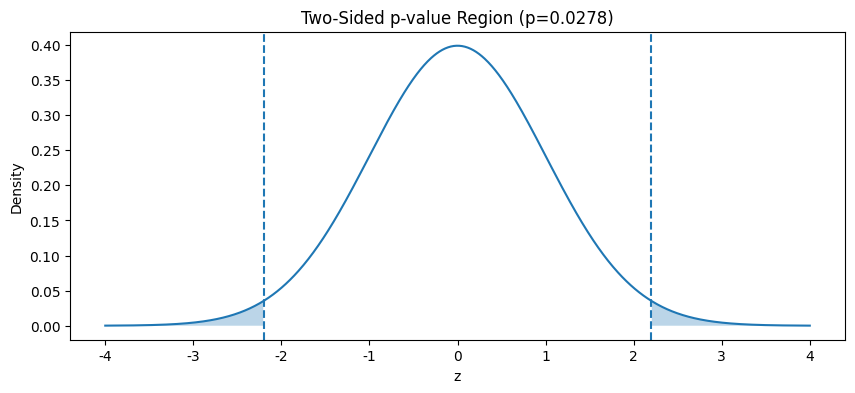

In [25]:
z_score = 2.2
xx = np.linspace(-4,4,1000)
pdf = stats.norm.pdf(xx)
p = 2*(1-stats.norm.cdf(abs(z_score)))

plt.plot(xx,pdf)
plt.fill_between(xx,0,pdf,where=(np.abs(xx)>=abs(z_score)),alpha=0.3)
plt.axvline(z_score,linestyle="--")
plt.axvline(-z_score,linestyle="--")
plt.title(f"Two-Sided p-value Region (p={p:.4f})")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

## 결과

양쪽 꼬리의 음영 영역이 p-value에 해당합니다.

## 결과 해석

p-value는 **H0가 참일 확률**이 아닙니다. H0가 참이라는 조건 아래 데이터의 극단성을 측정합니다.

# 2-13. 유의수준과 Type I Error

## 내용 설명

유의수준 $lpha$는 귀무가설이 실제로 참일 때 잘못 기각할 장기적 오류율을 통제하는 기준입니다.

## 수식

$$
\alpha=0.05
$$

$$
P(\text{Reject }H_0\mid H_0\text{ true})=\alpha
$$

## 실습 코드

In [26]:
reps = 3000
rejects = 0

for _ in range(reps):
    s = np.random.normal(0,1,30)
    _, p = stats.ttest_1samp(s,0)
    if p < 0.05:
        rejects += 1

print("Estimated Type I Error Rate =", rejects/reps)

Estimated Type I Error Rate = 0.05733333333333333


## 결과

추정된 Type I Error Rate가 대체로 0.05 근처로 나타납니다.

## 결과 해석

5% 유의수준은 오류 가능성을 없애는 것이 아니라 장기적으로 약 5% 수준으로 통제한다는 뜻입니다.

# 2-14. Type II Error와 Power

## 내용 설명

실제 효과가 있는데도 H0를 기각하지 못하는 오류가 Type II Error입니다.
검정력(Power)은 실제 효과를 올바르게 탐지할 확률입니다.

## 수식

$$
Power=1-\beta
$$

여기서 $\beta$는 Type II Error 확률입니다.

## 실습 코드

,Sample Size,Power
0,10,0.200000
1,20,0.410667
2,30,0.578667
3,50,0.791333
4,100,0.981333
5,200,0.999333


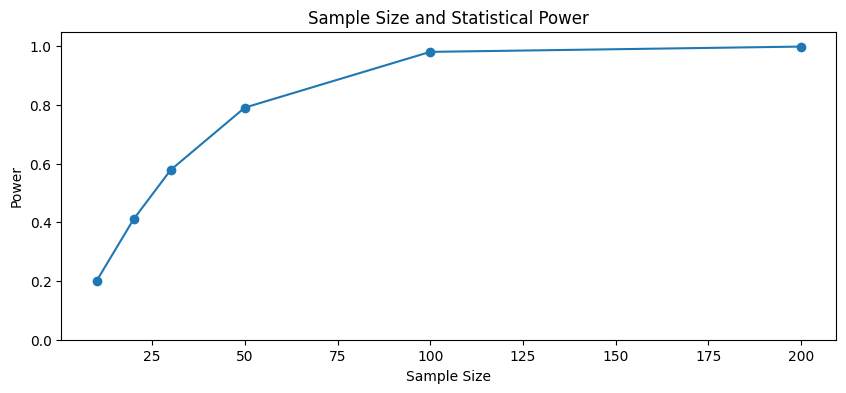

In [27]:
sample_sizes = [10,20,30,50,100,200]
rows = []

for n in sample_sizes:
    reject = 0
    for _ in range(1500):
        s = np.random.normal(0.4,1,n)
        _, p = stats.ttest_1samp(s,0)
        if p < 0.05:
            reject += 1
    rows.append([n, reject/1500])

power_df = pd.DataFrame(rows, columns=["Sample Size","Power"])
display(power_df)

plt.plot(power_df["Sample Size"], power_df["Power"], marker="o")
plt.ylim(0,1.05)
plt.title("Sample Size and Statistical Power")
plt.xlabel("Sample Size")
plt.ylabel("Power")
plt.show()

## 결과

표본크기가 커질수록 검정력이 높아지는 모습을 볼 수 있습니다.

## 결과 해석

유의하지 않은 결과가 반드시 효과가 없다는 뜻은 아닙니다. 표본이 너무 작아 검정력이 부족했을 수도 있습니다.

# 2-15. 회귀분석 Regression

## 내용 설명

회귀분석은 X와 Y의 관계를 함수 형태로 표현합니다.

## 수식

$$
Y=\beta_0+\beta_1X+\epsilon
$$

- $\beta_0$: 절편
- $\beta_1$: 기울기
- $\epsilon$: 설명하지 못한 부분

## 실습 코드

In [28]:
n = 120
X = np.random.uniform(0,10,n)
Y = 10 + 2.3*X + np.random.normal(0,4,n)

Xc = sm.add_constant(X)
model = sm.OLS(Y,Xc).fit()

display(pd.DataFrame({
    "Coefficient": model.params,
    "Std. Error": model.bse,
    "t-statistic": model.tvalues,
    "p-value": model.pvalues
}, index=["Intercept","X"]))

print("R-squared =", model.rsquared)

,Coefficient,Std. Error,t-statistic,p-value
Intercept,9.473920,0.662735,14.295182,1.627487e-27
X,2.384048,0.117428,20.302228,2.622744e-40


R-squared = 0.7774342744096995


## 결과

절편, 기울기, 표준오차, t값, p-value, R²가 출력됩니다.

## 결과 해석

기울기는 X가 1단위 증가할 때 Y가 평균적으로 얼마나 변하는지 나타냅니다. 다만 단순 회귀계수를 곧바로 인과효과로 해석하면 안 됩니다.

# 2-16. OLS와 잔차

## 내용 설명

OLS는 실제값과 예측값의 차이 제곱합을 최소화하는 회귀선을 찾습니다.

## 수식

잔차:

$$
e_i=y_i-\hat{y}_i
$$

OLS:

$$
\min_{\beta_0,\beta_1}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

## 실습 코드

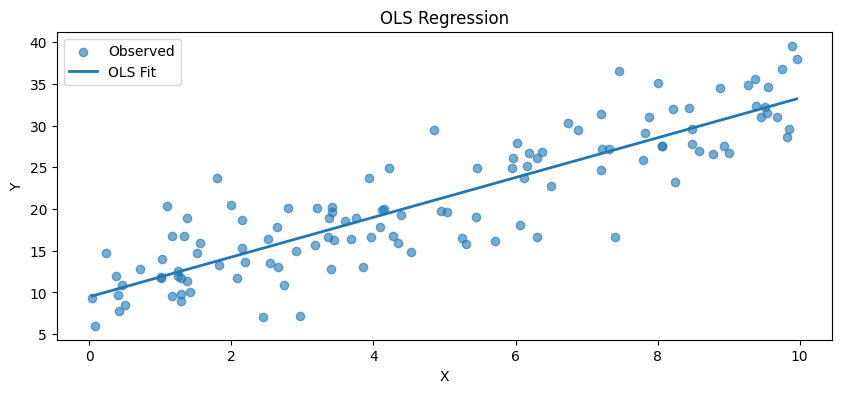

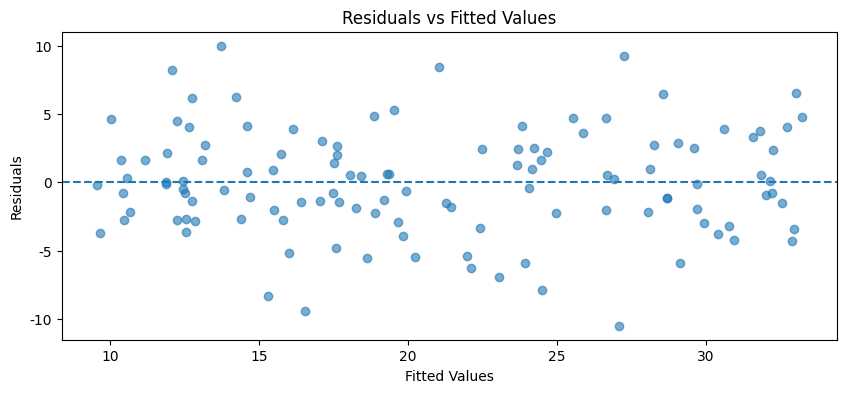

In [29]:
pred = model.predict(Xc)
resid = Y - pred
order = np.argsort(X)

plt.scatter(X,Y,alpha=0.6,label="Observed")
plt.plot(X[order],pred[order],linewidth=2,label="OLS Fit")
plt.title("OLS Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

plt.scatter(pred,resid,alpha=0.6)
plt.axhline(0,linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

## 결과

첫 번째 그래프는 회귀선, 두 번째 그래프는 잔차 패턴을 보여줍니다.

## 결과 해석

잔차가 0 주변에 무작위로 흩어져 있다면 기본적인 선형 모형 가정과 비교적 잘 맞습니다. 패턴이 남으면 모형이 구조를 놓치고 있을 수 있습니다.

# 2-17. R²와 Spurious Regression

## 내용 설명

R²는 전체 변동 중 회귀모형이 설명한 비율입니다. 하지만 시계열에서는 높은 R²가 반드시 좋은 모델을 의미하지 않습니다.

## 수식

$$
R^2
=
1-\frac{SSE}{SST}
$$

## 실습 코드

In [30]:
T = 500
rw1 = np.cumsum(np.random.normal(0,1,T))
rw2 = np.cumsum(np.random.normal(0,1,T))

sp_model = sm.OLS(rw2, sm.add_constant(rw1)).fit()

print("Level regression R-squared =", sp_model.rsquared)
print("Slope p-value =", sp_model.pvalues[1])

drw1 = np.diff(rw1)
drw2 = np.diff(rw2)
diff_model = sm.OLS(drw2, sm.add_constant(drw1)).fit()

display(pd.DataFrame({
    "Model": ["Level Regression","Difference Regression"],
    "R-squared": [sp_model.rsquared, diff_model.rsquared],
    "Slope p-value": [sp_model.pvalues[1], diff_model.pvalues[1]]
}))

Level regression R-squared = 0.059067218678721
Slope p-value = 3.7208731873249606e-08


,Model,R-squared,Slope p-value
0,Level Regression,0.059067,3.720873e-08
1,Difference Regression,0.000026,9.101718e-01


## 결과

수준값에서는 높은 R²와 유의한 p-value가 나타날 수 있지만 차분 후 관계가 약해질 수 있습니다.

## 결과 해석

비정상 시계열끼리 회귀하면 허위회귀가 발생할 수 있으므로 시계열에서는 정상성 진단이 중요합니다.

# 3부. 통계에서 시계열로

# 3-1. Lag

## 내용 설명

Lag는 현재를 기준으로 과거 몇 시점 전의 값인지를 의미합니다.

## 수식

$$
Y_t,\quad Y_{t-1},\quad Y_{t-2},\ldots,Y_{t-k}
$$

## 실습 코드

In [31]:
series = pd.Series([10,12,11,15,14], name="Y_t")
lag_df = pd.DataFrame({
    "Y_t": series,
    "Y_t-1": series.shift(1),
    "Y_t-2": series.shift(2)
})
display(lag_df)

,Y_t,Y_t-1,Y_t-2
0,10,NaN,NaN
1,12,10.0,NaN
2,11,12.0,10.0
3,15,11.0,12.0
4,14,15.0,11.0


## 결과

현재값과 1시점 전, 2시점 전 값이 같은 표에 정렬되어 출력됩니다.

## 결과 해석

Lag는 시계열분석에서 현재와 과거의 의존성을 표현하는 기본 언어입니다.

# 3-2. 자기상관 Autocorrelation

## 내용 설명

자기상관은 한 시계열의 현재값과 과거값 사이의 상관관계입니다.

## 수식

일반 상관:

$$
Corr(X,Y)
$$

자기상관:

$$
Corr(Y_t,Y_{t-k})
$$

## 실습 코드

Lag-1 autocorrelation = 0.7067018605764381


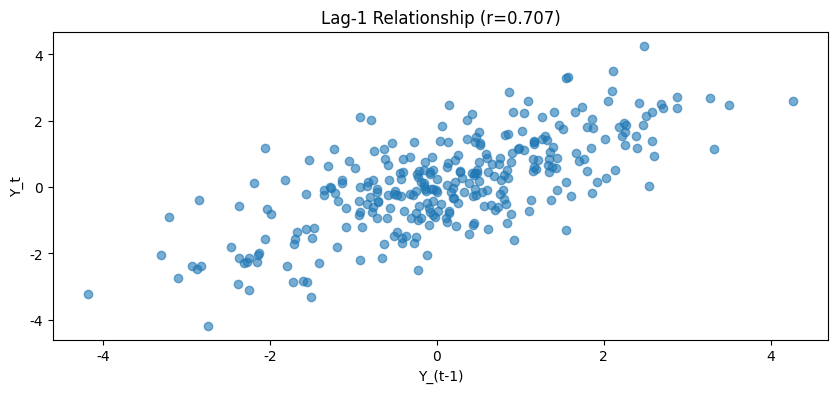

In [32]:
T = 300
phi = 0.75
eps = np.random.normal(0,1,T)
ar1 = np.zeros(T)

for t in range(1,T):
    ar1[t] = phi*ar1[t-1] + eps[t]

lag1_corr = np.corrcoef(ar1[1:], ar1[:-1])[0,1]
print("Lag-1 autocorrelation =", lag1_corr)

plt.scatter(ar1[:-1], ar1[1:], alpha=0.6)
plt.title(f"Lag-1 Relationship (r={lag1_corr:.3f})")
plt.xlabel("Y_(t-1)")
plt.ylabel("Y_t")
plt.show()

## 결과

현재값과 직전값 사이에 양의 상관이 나타납니다.

## 결과 해석

AR(1)에서는 현재값이 과거값의 영향을 받기 때문에 자기상관이 생깁니다.

# 3-3. 자기공분산과 자기상관계수

## 내용 설명

정상 시계열에서는 공분산 구조가 절대 시점이 아니라 lag에 의존합니다.

## 수식

자기공분산:

$$
\gamma_k=Cov(Y_t,Y_{t-k})
$$

자기상관계수:

$$
\rho_k=\frac{\gamma_k}{\gamma_0}
$$

## 실습 코드

In [33]:
def sample_autocovariance(x, k):
    x = np.asarray(x)
    xbar = x.mean()
    return np.mean((x[k:] - xbar) * (x[:-k] - xbar)) if k > 0 else np.mean((x-xbar)**2)

rows = []
gamma0 = sample_autocovariance(ar1,0)

for k in range(1,6):
    gk = sample_autocovariance(ar1,k)
    rows.append([k,gk,gk/gamma0])

display(pd.DataFrame(rows, columns=["Lag","Autocovariance","Autocorrelation"]))

,Lag,Autocovariance,Autocorrelation
0,1,1.358482,0.704725
1,2,1.013671,0.525851
2,3,0.705304,0.365883
3,4,0.461402,0.239357
4,5,0.336789,0.174712


## 결과

Lag별 자기공분산과 자기상관계수가 표로 출력됩니다.

## 결과 해석

자기상관계수는 lag별 관계를 표준화하여 비교할 수 있게 해줍니다.

# 3-4. ACF

## 내용 설명

ACF는 여러 lag에서의 자기상관계수를 한 번에 시각화합니다.

## 수식

$$
ACF=\{\rho_1,\rho_2,\rho_3,\ldots,\rho_k\}
$$

## 실습 코드

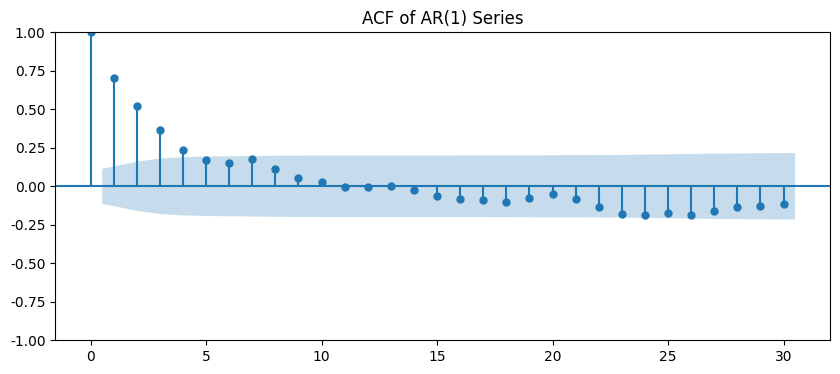

In [34]:
plot_acf(ar1, lags=30, alpha=0.05)
plt.title("ACF of AR(1) Series")
plt.show()

## 결과

AR(1) 시계열에서는 ACF가 lag가 증가할수록 점차 감소하는 전형적인 패턴을 보입니다.

## 결과 해석

ACF는 시계열의 **기억 구조(memory structure)**를 보여주며 ARIMA 모형 식별의 중요한 출발점입니다.

# 3-5. 정상성 Stationarity

## 내용 설명

약정상성은 평균, 분산, 자기공분산 구조가 시간에 따라 안정적인 성질을 의미합니다.

## 수식

$$
E(Y_t)=\mu
$$

$$
Var(Y_t)=\sigma^2
$$

$$
Cov(Y_t,Y_{t-k})=\gamma_k
$$

## 실습 코드

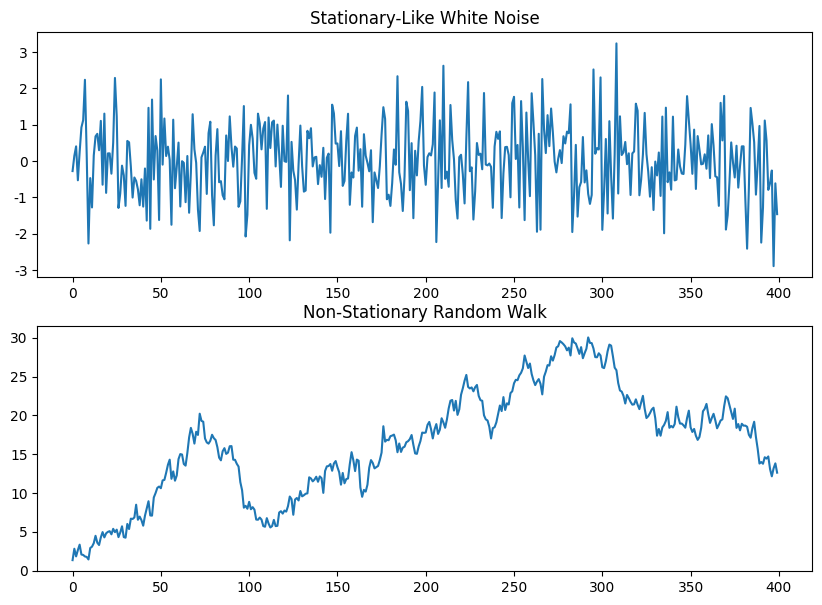

In [35]:
white = np.random.normal(0,1,400)
random_walk = np.cumsum(np.random.normal(0,1,400))

fig, axes = plt.subplots(2,1, figsize=(10,7))
axes[0].plot(white)
axes[0].set_title("Stationary-Like White Noise")
axes[1].plot(random_walk)
axes[1].set_title("Non-Stationary Random Walk")
plt.show()

## 결과

White Noise는 평균 주변에서 움직이는 반면 Random Walk는 수준이 크게 이동합니다.

## 결과 해석

정상성은 평균이 0이라는 뜻이 아니라 **통계적 구조가 시간에 따라 안정적**이라는 뜻입니다.

# 3-6. White Noise

## 내용 설명

White Noise는 예측 가능한 구조가 거의 남아 있지 않은 무작위 충격 과정입니다.

## 수식

$$
\epsilon_t\sim WN(0,\sigma^2)
$$

$$
E(\epsilon_t)=0
$$

$$
Var(\epsilon_t)=\sigma^2
$$

$$
Cov(\epsilon_t,\epsilon_{t-k})=0
$$

## 실습 코드

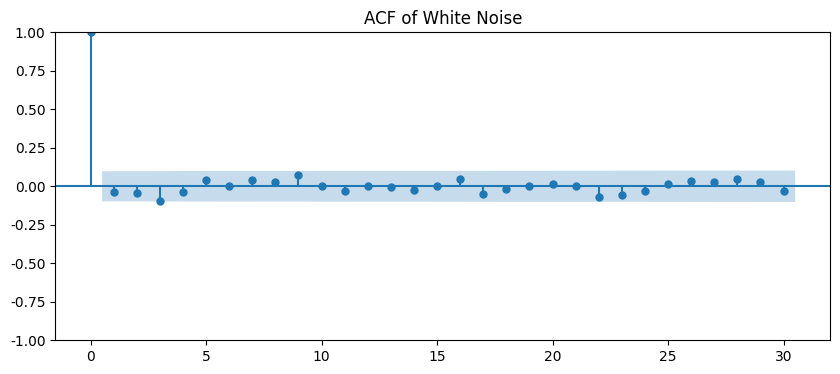

In [36]:
plot_acf(white, lags=30, alpha=0.05)
plt.title("ACF of White Noise")
plt.show()

## 결과

대부분의 lag에서 자기상관이 0 근처에 나타납니다.

## 결과 해석

좋은 시계열모형의 잔차는 가능한 한 White Noise에 가까워야 합니다.

# 3-7. White Noise와 정상성

## 내용 설명

White Noise는 정상적이지만 모든 정상 시계열이 White Noise인 것은 아닙니다.
AR(1)처럼 정상적이면서 자기상관 구조를 가진 과정도 존재합니다.

## 수식

개념적으로:

$$
White\ Noise \subset Stationary\ Processes
$$

## 실습 코드

In [37]:
print("White noise lag-1 correlation:",
      np.corrcoef(white[1:],white[:-1])[0,1])

print("AR(1) lag-1 correlation:",
      np.corrcoef(ar1[1:],ar1[:-1])[0,1])

White noise lag-1 correlation: -0.03414986092392682
AR(1) lag-1 correlation: 0.7067018605764381


## 결과

White Noise의 lag-1 상관은 0에 가깝고, AR(1)은 더 큰 값을 가질 수 있습니다.

## 결과 해석

정상성은 자기상관이 없다는 뜻이 아닙니다. White Noise는 정상 과정 중 특별히 자기상관이 없는 경우입니다.

# 3-8. Random Walk

## 내용 설명

Random Walk는 현재값이 직전 값과 새로운 충격의 합으로 결정되는 과정입니다.

## 수식

$$
Y_t=Y_{t-1}+\epsilon_t
$$

또는

$$
Y_t=Y_0+\sum_{i=1}^{t}\epsilon_i
$$

## 실습 코드

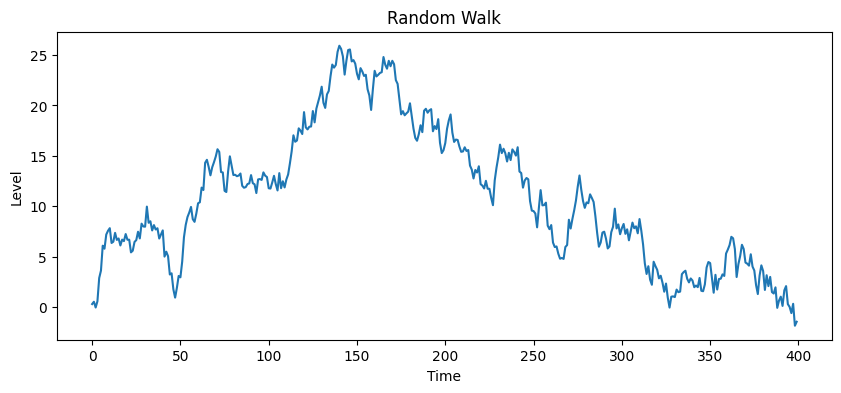

In [38]:
rw = np.cumsum(np.random.normal(0,1,400))

plt.plot(rw)
plt.title("Random Walk")
plt.xlabel("Time")
plt.ylabel("Level")
plt.show()

## 결과

Random Walk는 장기적으로 수준이 크게 이동하고 충격이 누적됩니다.

## 결과 해석

Random Walk는 대표적인 비정상 시계열이며, Unit Root와 직접 연결됩니다.

# 3-9. Unit Root

## 내용 설명

AR(1)에서 계수 $\phi$가 1이면 Random Walk가 됩니다.

## 수식

$$
Y_t=\phi Y_{t-1}+\epsilon_t
$$

$$
\phi=1
\Rightarrow
Y_t=Y_{t-1}+\epsilon_t
$$

## 실습 코드

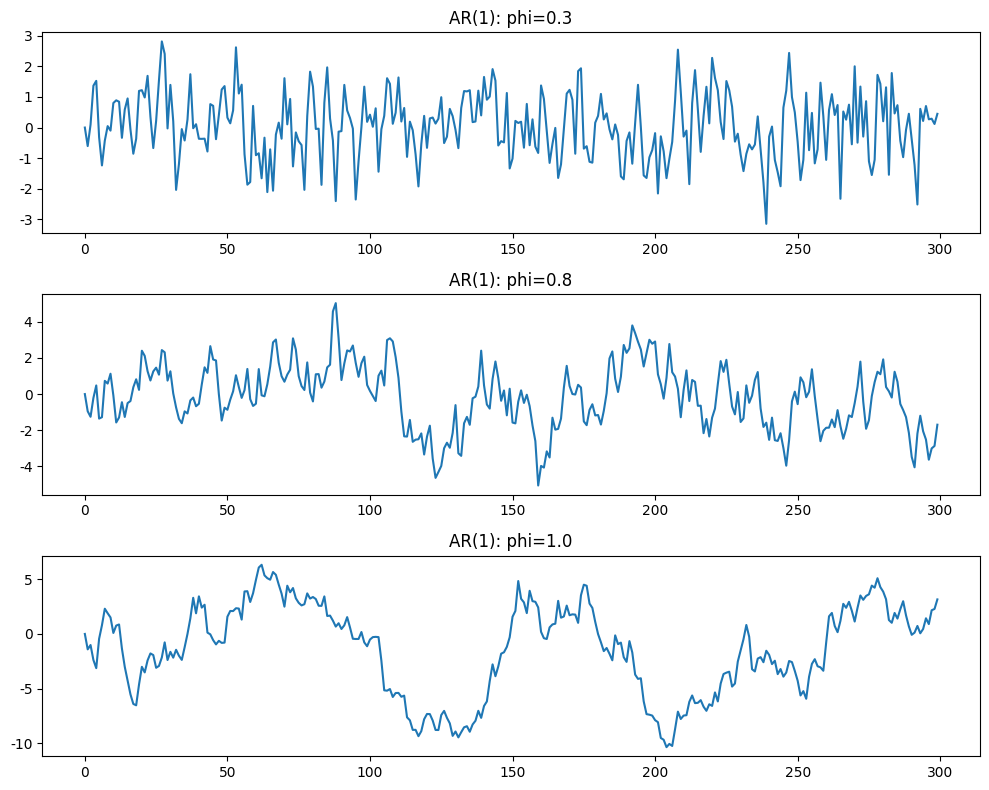

In [39]:
phis = [0.3,0.8,1.0]
T = 300

fig, axes = plt.subplots(3,1, figsize=(10,8))

for ax, phi in zip(axes, phis):
    eps = np.random.normal(0,1,T)
    y = np.zeros(T)
    for t in range(1,T):
        y[t] = phi*y[t-1] + eps[t]
    ax.plot(y)
    ax.set_title(f"AR(1): phi={phi}")

plt.tight_layout()
plt.show()

## 결과

$\phi$가 1에 가까워질수록 충격의 지속성이 강해집니다.

## 결과 해석

$\phi=1$인 Unit Root 과정에서는 충격이 사라지지 않고 누적되므로 비정상성이 나타납니다.

# 3-10. 차분 Differencing

## 내용 설명

차분은 비정상 시계열의 수준 변화를 제거해 정상성에 가까운 형태로 변환할 때 자주 사용합니다.

## 수식

$$
\Delta Y_t
=
Y_t-Y_{t-1}
$$

## 실습 코드

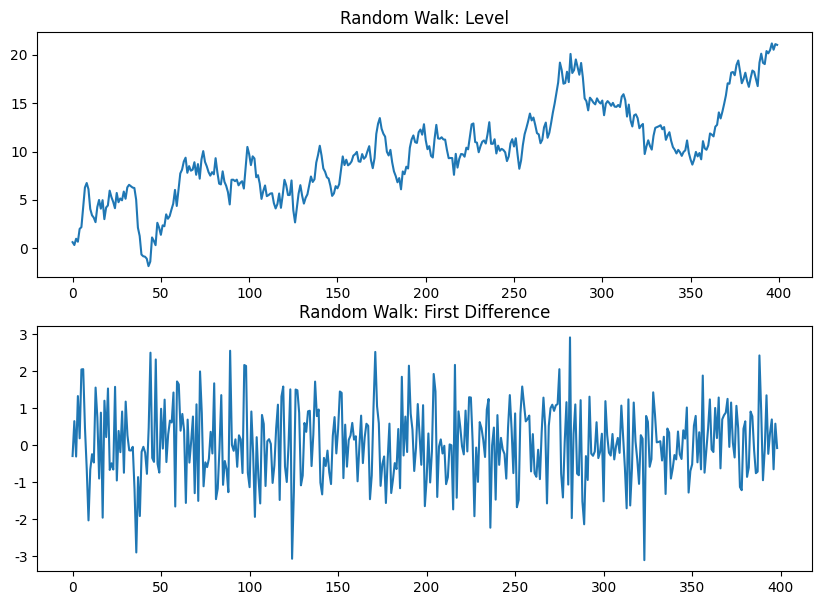

In [40]:
rw = np.cumsum(np.random.normal(0,1,400))
rw_diff = np.diff(rw)

fig, axes = plt.subplots(2,1, figsize=(10,7))
axes[0].plot(rw)
axes[0].set_title("Random Walk: Level")
axes[1].plot(rw_diff)
axes[1].set_title("Random Walk: First Difference")
plt.show()

## 결과

수준값은 비정상적으로 움직이지만 1차 차분은 평균 주변에서 안정적으로 움직이는 형태가 됩니다.

## 결과 해석

ARIMA의 I(Integrated)는 이러한 차분과 연결됩니다.

# 3-11. ADF Test

## 내용 설명

ADF는 Unit Root 존재 여부를 검정합니다.

## 수식

$$
H_0:\text{Unit Root Exists}
$$

$$
H_1:\text{Stationary}
$$

ADF의 대표적 회귀형태:

$$
\Delta Y_t
=
\alpha
+
\gamma Y_{t-1}
+
\sum_{i=1}^{p}\delta_i\Delta Y_{t-i}
+
\epsilon_t
$$

귀무가설은

$$
H_0:\gamma=0
$$

입니다.

## 실습 코드

In [41]:
def adf_table(series, name):
    stat, p, usedlag, nobs, crit, icbest = adfuller(pd.Series(series).dropna(), autolag="AIC")
    return pd.DataFrame({
        "Series": [name],
        "ADF Statistic": [stat],
        "p-value": [p],
        "Used Lag": [usedlag],
        "Decision (5%)": ["Reject H0" if p < 0.05 else "Fail to Reject H0"]
    })

display(adf_table(white, "White Noise"))
display(adf_table(rw, "Random Walk"))

,Series,ADF Statistic,p-value,Used Lag,Decision (5%)
0,White Noise,-13.053648,2.116678e-24,2,Reject H0


,Series,ADF Statistic,p-value,Used Lag,Decision (5%)
0,Random Walk,-1.676047,0.443494,2,Fail to Reject H0


## 결과

White Noise에서는 보통 p-value가 작고, Random Walk에서는 p-value가 상대적으로 크게 나타납니다.

## 결과 해석

ADF는 **비정상(Unit Root)**을 귀무가설로 둡니다. 따라서 p-value가 작으면 Unit Root 귀무가설을 기각하고 정상성을 지지하는 방향입니다.

# 3-12. KPSS Test

## 내용 설명

KPSS는 ADF와 반대 방향에서 정상성을 점검합니다.

## 수식

$$
H_0:\text{Stationary}
$$

$$
H_1:\text{Non-stationary}
$$

## 실습 코드

In [42]:
def kpss_table(series, name):
    stat, p, lags, crit = kpss(pd.Series(series).dropna(), regression="c", nlags="auto")
    return pd.DataFrame({
        "Series": [name],
        "KPSS Statistic": [stat],
        "p-value": [p],
        "Used Lag": [lags],
        "Decision (5%)": ["Reject H0" if p < 0.05 else "Fail to Reject H0"]
    })

display(kpss_table(white, "White Noise"))
display(kpss_table(rw, "Random Walk"))

/tmp/ipykernel_2891/1577495757.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  stat, p, lags, crit = kpss(pd.Series(series).dropna(), regression="c", nlags="auto")


,Series,KPSS Statistic,p-value,Used Lag,Decision (5%)
0,White Noise,0.11806,0.1,9,Fail to Reject H0


/tmp/ipykernel_2891/1577495757.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  stat, p, lags, crit = kpss(pd.Series(series).dropna(), regression="c", nlags="auto")


,Series,KPSS Statistic,p-value,Used Lag,Decision (5%)
0,Random Walk,2.634685,0.01,11,Reject H0


## 결과

White Noise에서는 정상성 귀무가설을 기각하지 못하고, Random Walk에서는 정상성 귀무가설을 기각하는 경우가 일반적입니다.

## 결과 해석

기억하기 쉽게 말하면 **ADF는 비정상에서 시작하고, KPSS는 정상에서 시작합니다.**

# 3-13. ADF와 KPSS 종합판단

## 내용 설명

ADF와 KPSS는 귀무가설이 반대이므로 함께 사용하면 정상성에 대한 증거를 더 입체적으로 볼 수 있습니다.

## 실습 코드

In [43]:
def stationarity_diagnosis(series, alpha=0.05):
    s = pd.Series(series).dropna()

    adf_p = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]

    if adf_p < alpha and kpss_p >= alpha:
        verdict = "Evidence supports stationarity"
    elif adf_p >= alpha and kpss_p < alpha:
        verdict = "Evidence supports non-stationarity"
    else:
        verdict = "Mixed / inconclusive evidence"

    return pd.Series({
        "ADF p-value": adf_p,
        "KPSS p-value": kpss_p,
        "Assessment": verdict
    })

display(pd.DataFrame({
    "White Noise": stationarity_diagnosis(white),
    "Random Walk": stationarity_diagnosis(rw),
    "Differenced Random Walk": stationarity_diagnosis(np.diff(rw))
}).T)

/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]


,ADF p-value,KPSS p-value,Assessment
White Noise,0.0,0.1,Evidence supports stationarity
Random Walk,0.443494,0.01,Evidence supports non-stationarity
Differenced Random Walk,0.0,0.1,Evidence supports stationarity


## 결과

White Noise, Random Walk, 차분 Random Walk의 ADF와 KPSS 결과가 함께 출력됩니다.

## 결과 해석

두 검정이 일치하면 판단이 비교적 명확하지만, 충돌하면 trend, structural break, lag 설정, 표본 크기 등을 추가 점검해야 합니다.

# 3-14. Regression → Autoregression

## 내용 설명

Autoregression은 일반 회귀에서 설명변수 X 대신 자기 자신의 과거값을 사용하는 구조로 이해할 수 있습니다.

## 수식

일반 회귀:

$$
Y=\beta_0+\beta_1X+\epsilon
$$

AR(1):

$$
Y_t=c+\phi_1Y_{t-1}+\epsilon_t
$$

## 실습 코드

In [44]:
Y_ar = ar1[1:]
X_ar = sm.add_constant(ar1[:-1])

ar_model = sm.OLS(Y_ar, X_ar).fit()

display(pd.DataFrame({
    "Coefficient": ar_model.params,
    "p-value": ar_model.pvalues
}, index=["Intercept","Y_(t-1)"]))

print("R-squared =", ar_model.rsquared)

,Coefficient,p-value
Intercept,0.033561,5.592646e-01
Y_(t-1),0.711033,1.532361e-46


R-squared = 0.4994275197421991


## 결과

과거값 $Y_{t-1}$의 계수가 추정되어 출력됩니다.

## 결과 해석

AR은 낯선 별도 모델이 아니라 **자기 자신의 과거에 대한 회귀**라고 이해할 수 있습니다.

# 3-15. 잔차와 White Noise

## 내용 설명

좋은 시계열 모형이라면 잔차에 체계적인 자기상관이 거의 남아 있지 않아야 합니다.

## 수식

잔차:

$$
e_t=Y_t-\hat{Y}_t
$$

이상적인 경우:

$$
E(e_t)\approx0,\qquad Cov(e_t,e_{t-k})\approx0
$$

## 실습 코드

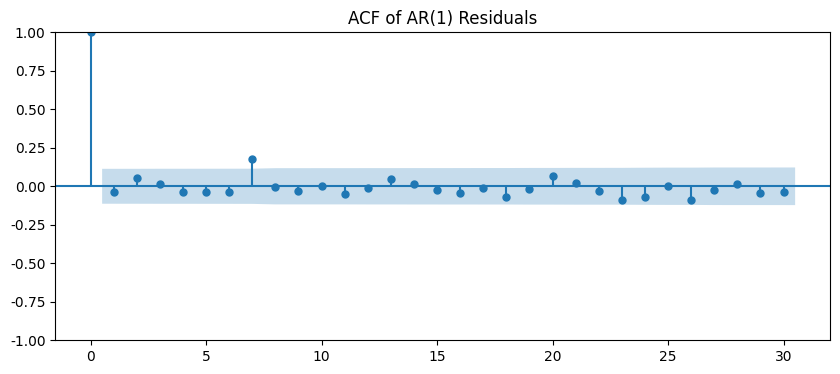

In [45]:
ar_resid = ar_model.resid

plot_acf(ar_resid, lags=30, alpha=0.05)
plt.title("ACF of AR(1) Residuals")
plt.show()

## 결과

잔차 ACF의 대부분 막대가 신뢰구간 안에 들어가면 큰 자기상관이 남지 않았다고 볼 수 있습니다.

## 결과 해석

잔차에 강한 자기상관이 남으면 추가 lag, 계절성, 추세, 외생변수 등을 검토해야 합니다.

# 3-16. 점예측과 Prediction Interval

## 내용 설명

시계열 예측에서는 하나의 점예측뿐 아니라 미래값의 불확실성 범위를 함께 보는 것이 중요합니다.

## 수식

점예측:

$$
\hat{Y}_{t+1}
$$

예측구간:

$$
P(L_{t+1}\le Y_{t+1}\le U_{t+1})\approx 1-\alpha
$$

## 실습 코드

,X,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2,14.242015,0.480647,13.290203,15.193827,6.517685,21.966345
1,4,19.010110,0.364884,18.287542,19.732679,11.310666,26.709554
2,6,23.778205,0.381540,23.022653,24.533758,16.075596,31.480815
3,8,28.546301,0.517996,27.520527,29.572074,20.812508,36.280093


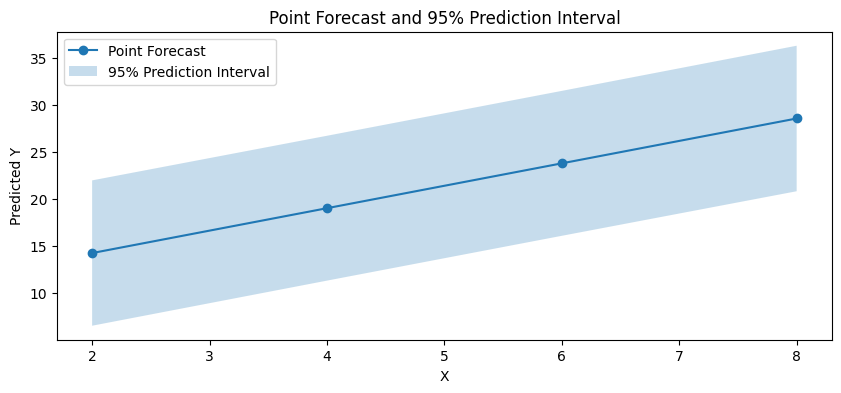

In [46]:
new_x = np.array([2,4,6,8])
new_X = sm.add_constant(new_x)

pred_frame = model.get_prediction(new_X).summary_frame(alpha=0.05)
pred_frame.insert(0, "X", new_x)
display(pred_frame)

plt.plot(pred_frame["X"], pred_frame["mean"], marker="o", label="Point Forecast")
plt.fill_between(
    pred_frame["X"],
    pred_frame["obs_ci_lower"],
    pred_frame["obs_ci_upper"],
    alpha=0.25,
    label="95% Prediction Interval"
)
plt.title("Point Forecast and 95% Prediction Interval")
plt.xlabel("X")
plt.ylabel("Predicted Y")
plt.legend()
plt.show()

## 결과

점예측선과 95% Prediction Interval이 함께 표시됩니다.

## 결과 해석

의사결정에서는 예측값 자체뿐 아니라 예측이 얼마나 불확실한지도 중요합니다.

# 4. 전체 진단 Workflow

## 내용 설명

마지막으로 하나의 시계열에 대해 다음 절차를 한 번에 수행합니다.

1. 원시 시계열 확인
2. 기술통계
3. ACF
4. ADF
5. KPSS
6. 1차 차분
7. 차분 후 ADF / KPSS

## 수식

차분:

$$
\Delta Y_t=Y_t-Y_{t-1}
$$

ADF:

$$
H_0:\text{Unit Root}
$$

KPSS:

$$
H_0:\text{Stationary}
$$

## 실습 코드

Descriptive statistics


,RandomWalk
count,400.000000
mean,9.951901
std,4.658157
min,-1.853972
25%,6.679756
50%,9.753617
75%,12.630877
max,21.184660


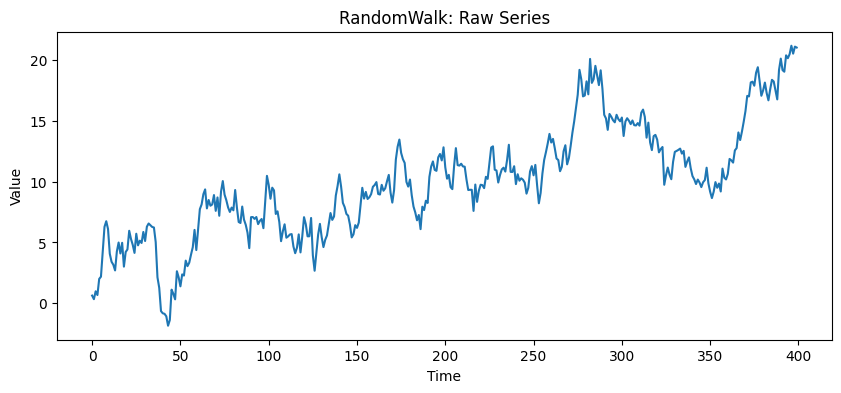

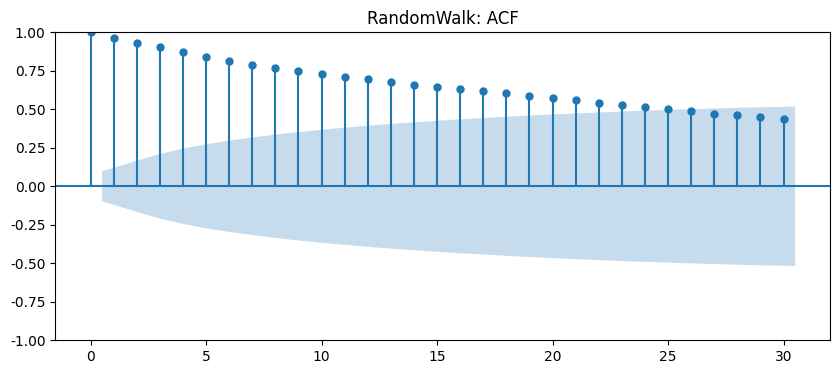

/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]


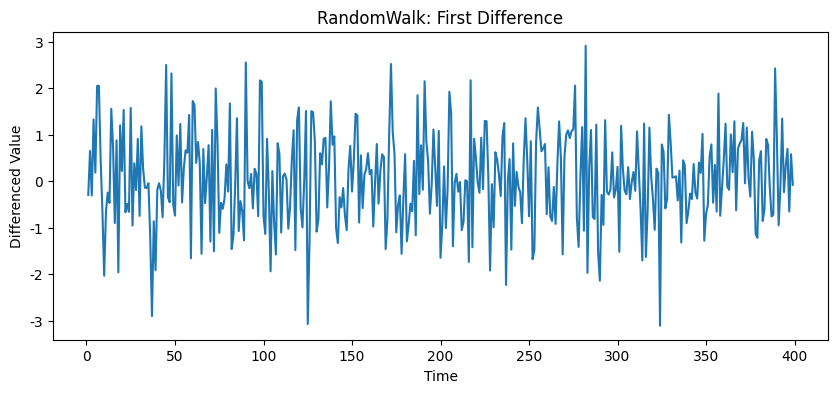

/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]


,ADF p-value,KPSS p-value,Assessment
Level,0.443494,0.01,Evidence supports non-stationarity
First Difference,0.0,0.1,Evidence supports stationarity


,ADF p-value,KPSS p-value,Assessment
Level,0.443494,0.01,Evidence supports non-stationarity
First Difference,0.0,0.1,Evidence supports stationarity


In [47]:
def full_ts_diagnosis(series, name="Series", lags=30):
    s = pd.Series(series).dropna().reset_index(drop=True)

    print("Descriptive statistics")
    display(s.describe().to_frame(name=name))

    plt.plot(s)
    plt.title(f"{name}: Raw Series")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.show()

    plot_acf(s, lags=min(lags, max(5, len(s)//4)), alpha=0.05)
    plt.title(f"{name}: ACF")
    plt.show()

    level = stationarity_diagnosis(s)

    ds = s.diff().dropna()

    plt.plot(ds)
    plt.title(f"{name}: First Difference")
    plt.xlabel("Time")
    plt.ylabel("Differenced Value")
    plt.show()

    diff = stationarity_diagnosis(ds)

    result = pd.DataFrame({
        "Level": level,
        "First Difference": diff
    }).T

    display(result)
    return result

full_ts_diagnosis(rw, name="RandomWalk")

## 결과

Random Walk의 원시 시계열, ACF, 1차 차분 그래프와 함께 ADF/KPSS 종합 결과가 화면에 표시됩니다.

## 결과 해석

- 수준값이 비정상인지
- 자기상관이 얼마나 오래 지속되는지
- ADF와 KPSS가 같은 방향의 증거를 주는지
- 1차 차분 후 정상성이 개선되는지

를 한 번에 확인할 수 있습니다.

이 흐름은 이후 ARIMA 분석의 전처리와 직접 연결됩니다.

# 5. 선택 실습 — 실제 금융데이터

인터넷 연결이 가능한 경우 `yfinance`를 이용해 실제 시계열에도 같은 절차를 적용할 수 있습니다.

아래 코드는 `yfinance`의 컬럼이 MultiIndex로 반환되는 경우도 처리합니다.

## 수식

로그수익률:

$$
r_t
=
\ln(P_t)-\ln(P_{t-1})
$$

## 실습 코드

Price data


,Close
,AAPL
Date,
2023-01-03,125.070000
2023-01-04,126.360001
2023-01-05,125.019997
2023-01-06,129.619995
2023-01-09,130.149994


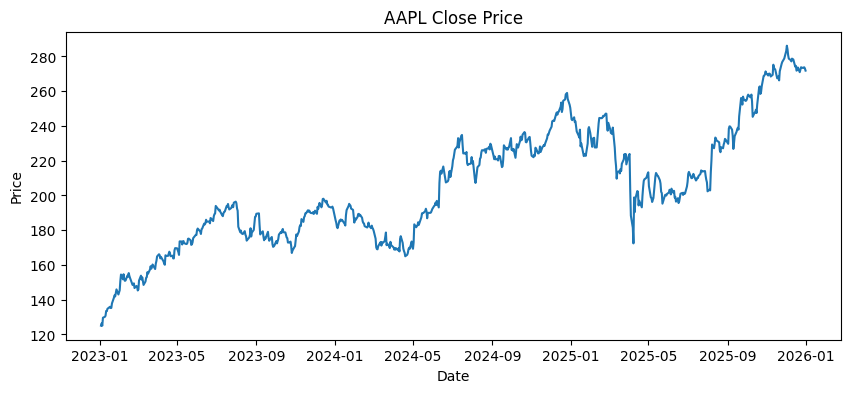

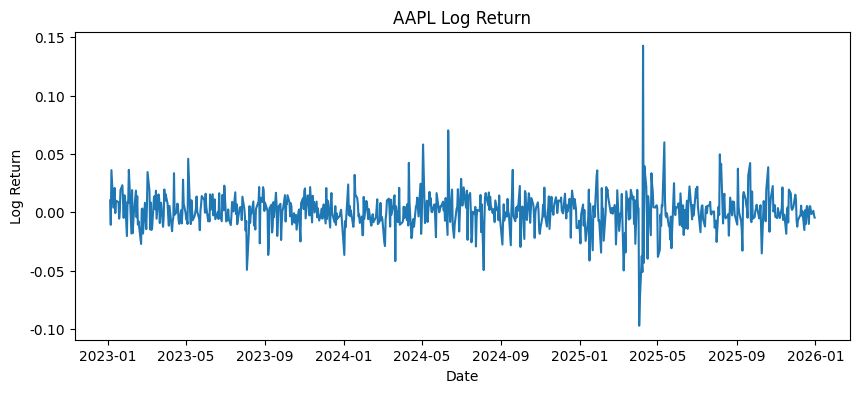

/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_2891/2974309635.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression="c", nlags="auto")[1]


,ADF p-value,KPSS p-value,Assessment
Price Level,0.558543,0.01,Evidence supports non-stationarity
Log Return,0.0,0.1,Evidence supports stationarity


In [48]:
import yfinance as yf

ticker = "AAPL"
df = yf.download(
    ticker,
    start="2023-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    close = df[("Close", ticker)].dropna()
else:
    close = df["Close"].dropna()

print("Price data")
display(close.head())

plt.plot(close.index, close.values)
plt.title(f"{ticker} Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

log_return = np.log(close).diff().dropna()

plt.plot(log_return.index, log_return.values)
plt.title(f"{ticker} Log Return")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

display(pd.DataFrame({
    "Price Level": stationarity_diagnosis(close.values),
    "Log Return": stationarity_diagnosis(log_return.values)
}).T)

## 결과

가격 수준과 로그수익률 그래프, 그리고 각각의 ADF/KPSS 결과가 표시됩니다.

## 결과 해석

실제 금융자료에서는 일반적으로 가격 수준은 비정상성을 보이고, 로그수익률은 상대적으로 정상성에 가까운 모습을 보이는 경우가 많습니다.

이는 시계열 분석에서 **변환(transform)**과 **차분(differencing)**이 중요한 이유를 보여줍니다.

# 6. 최종 연결

$$
\text{Data}
\rightarrow
\text{Mean / Variance}
\rightarrow
\text{Correlation}
\rightarrow
\text{Probability}
\rightarrow
\text{Sampling}
\rightarrow
\text{Inference}
\rightarrow
\text{Hypothesis Testing}
\rightarrow
\text{Regression}
\rightarrow
\text{Residual}
\rightarrow
\text{Lag / ACF}
\rightarrow
\text{Stationarity}
\rightarrow
\text{ADF / KPSS}
\rightarrow
\text{ARIMA}
$$

> **통계는 변동을 설명하고, 시계열은 시간에 따른 변동을 설명한다.**